In [1]:
%load_ext autoreload
%autoreload 2
import tensorflow as tf
import numpy as np
import gymnasium as gym

import jlab_opt_control.envs as custom_gym
import jlab_opt_control.agents as agents

import logging
run_openai_log = logging.getLogger("RunOpenAI")
run_openai_log.setLevel(logging.INFO)
logging.basicConfig(format='%(asctime)s %(levelname)s:%(name)s:%(message)s')

In [2]:
 # Environment
env_id = 'Pendulum-v1'
run_openai_log.info('Running env: {}'.format(env_id))

if env_id in gym.envs.registry:
    env = gym.make(env_id)
elif env_id in custom_gym.list_registered_modules():
    env = custom_gym.make(env_id)

num_states = env.observation_space.shape[0]
run_openai_log.info("Size of State Space ->  {}".format(num_states))
num_actions = env.action_space.shape[0]
run_openai_log.info("Size of Action Space ->  {}".format(num_actions))

upper_bound = env.action_space.high[0]
lower_bound = env.action_space.low[0]

run_openai_log.info("Max Value of Action ->  {}".format(upper_bound))
run_openai_log.info("Min Value of Action ->  {}".format(lower_bound))

2024-07-02 15:31:12,189 INFO:RunOpenAI:Running env: Pendulum-v1
2024-07-02 15:31:12,193 INFO:RunOpenAI:Size of State Space ->  3
2024-07-02 15:31:12,194 INFO:RunOpenAI:Size of Action Space ->  1
2024-07-02 15:31:12,194 INFO:RunOpenAI:Max Value of Action ->  2.0
2024-07-02 15:31:12,194 INFO:RunOpenAI:Min Value of Action ->  -2.0


In [3]:
import matplotlib.pyplot as plt

def plot_pendulum_space(ax, actions, critic_values, theta, omega, 
                        vmin=-200, vmax=0, label='Critic value'):
        r = 1 + omega / 16. # Radius corresponds to angular velocity
        t = 5 * np.abs(actions)# Size corresponds to torque magnitude

        x = -r * np.sin(theta)
        y = r * np.cos(theta)

        # Torque parallel to angular velocity
        mask = np.sign(actions * omega) >= 0
        im1 = ax.scatter(x[mask], y[mask], c=critic_values[mask], s=t[mask],
                         vmin=vmin, vmax=vmax,
                         cmap='viridis', marker='^', label='Accelerating torque')

        # Torque antiparallel to angular velocity
        mask = np.sign(actions * omega) < 0
        im1 = ax.scatter(x[mask], y[mask], c=critic_values[mask], s=t[mask],
                         vmin=vmin, vmax=vmax,
                         cmap='viridis', marker='v', label='Decelerating torque')
        
        plt.colorbar(im1, ax=ax, label=label)

        # Plot circle for pendulum path
        t = np.linspace(0, 2*np.pi, 100)
        ax.plot(np.cos(t), np.sin(t), color='black', zorder=2,
                label='Pendulum path')
        
        # Plot contours for angular velocity
        x = np.linspace(-1.5, 1.5, 100)
        y = np.linspace(-1.5, 1.5, 100)
        X, Y = np.meshgrid(x, y)
        R = np.sqrt(X**2 + Y**2)
        O = (R - 1) * 16
        O[np.abs(O) > 8] = np.nan

        im2 = ax.pcolormesh(X, Y, O, cmap='bwr', alpha=0.7, zorder=-2)
        plt.colorbar(im2, ax=ax, label='Angular velocity (rad/s)')

        ax.set(xticks=[], yticks=[], aspect='equal')
        ax.legend(loc='lower center', bbox_to_anchor=[0.5, 1],
                  ncol=2, framealpha=0)
        
        return ax

2024-07-02 15:31:34,923 ERROR:CfgLogger:Problem with key request using None
2024-07-02 15:31:34,928 INFO:Buffer:Buffer config saved successfully
2024-07-02 15:31:34,942 ERROR:Actor:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-07-02 15:31:34,947 ERROR:Actor:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-07-02 15:31:34,968 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-07-02 15:31:34,970 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-07-02 15:31:35,095 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-07-02 15:31:35,099 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number o

Attempting to load jlab_opt_control.agents with KerasTD3
Attempting to load jlab_opt_control.buffers with ER
Attempting to load jlab_opt_control.models with ActorFCNN
Attempting to load jlab_opt_control.models with ActorFCNN
Attempting to load jlab_opt_control.models with CriticFCNN
Attempting to load jlab_opt_control.models with CriticFCNN
Attempting to load jlab_opt_control.models with CriticFCNN
Attempting to load jlab_opt_control.models with CriticFCNN


2024-07-02 15:31:35,125 ERROR:CfgLogger:Problem with key request using 2
2024-07-02 15:31:35,126 ERROR:CfgLogger:Problem with key request using 2
2024-07-02 15:31:35,126 WARNING:TD3-Agent:[Errno 17] File exists: './results/Pendulum/KerasTD3-v0'


epoch_249


Text(0.5, 0.98, 'TD3 Agent')

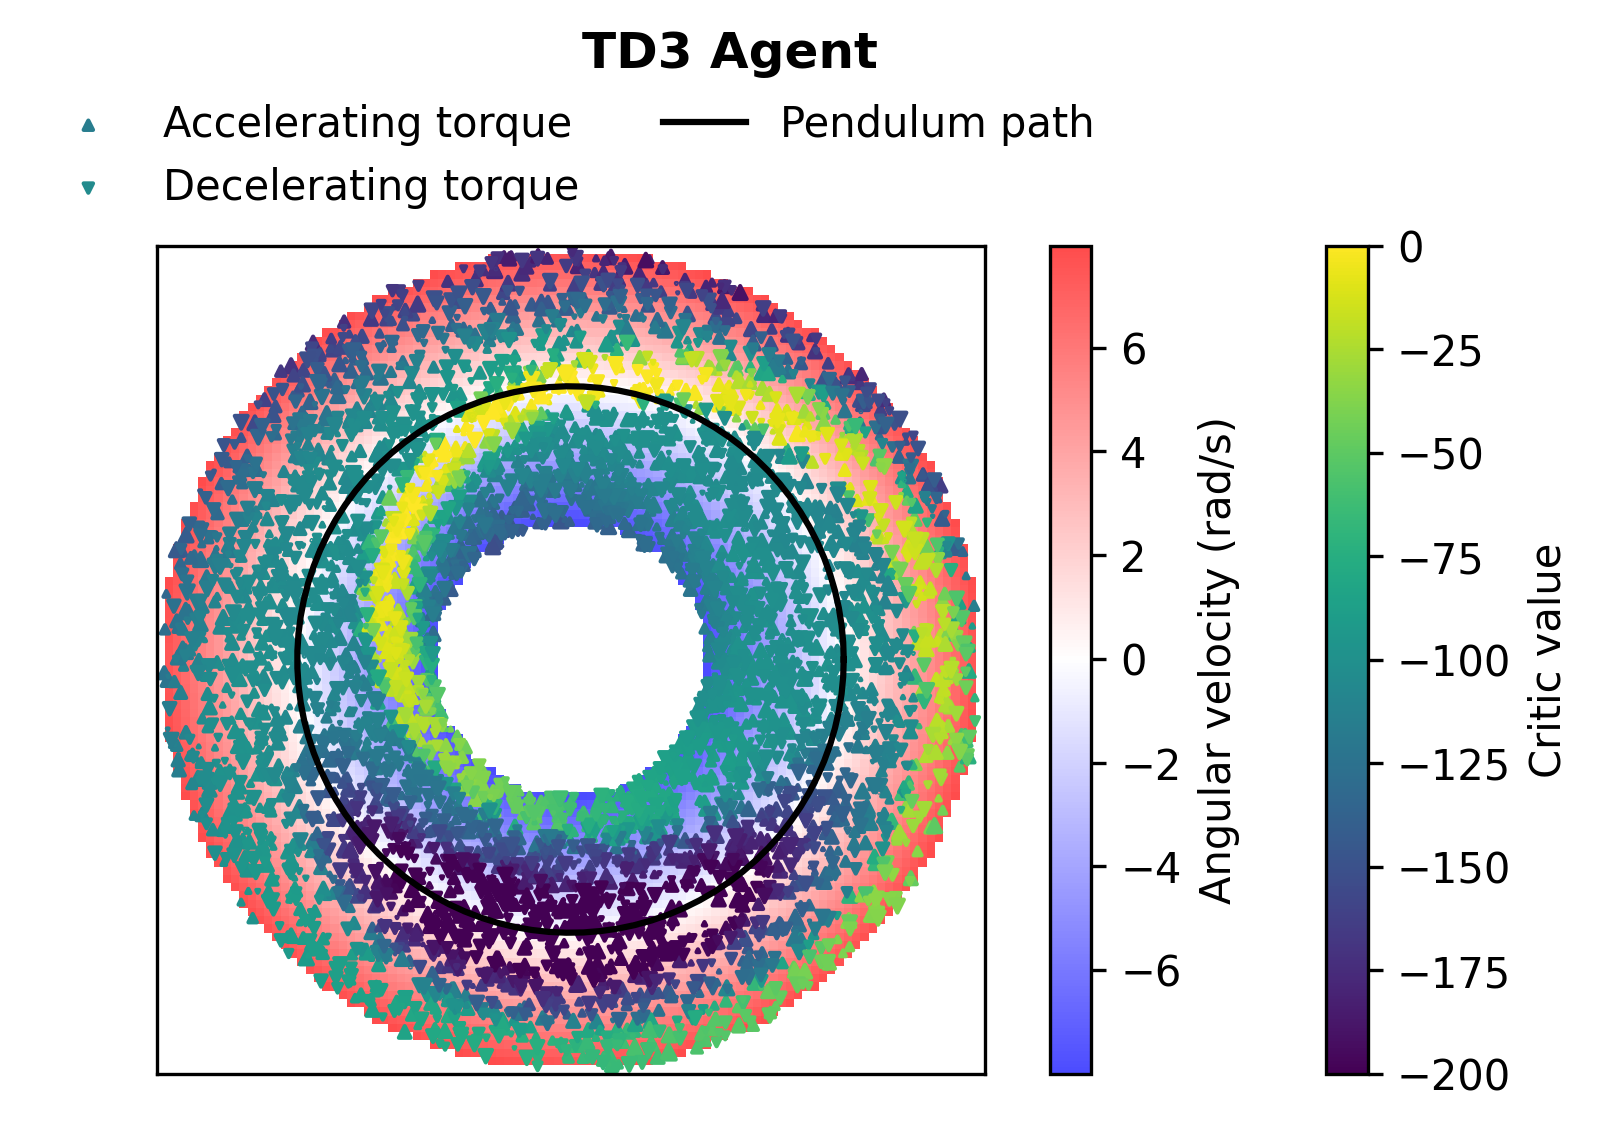

In [5]:
import os
import glob
import jlab_opt_control.agents as agents

logging.getLogger("Agent Registry").setLevel(logging.WARNING)
logging.getLogger("TD3-Agent").setLevel(logging.WARNING)

# Agent
agent_id = 'KerasTD3-v0'
logdir = glob.glob(f'./results/Pendulum/*{agent_id}*')[0]

buffer_type = 'ER-v0'
buffer_size = None

agent = agents.make(
    agent_id, 
    env=env, 
    logdir=logdir, 
    buffer_type=buffer_type, 
    buffer_size=buffer_size,
)

checkpoints = sorted(glob.glob(f'{logdir}/models/epoch_*'))
agent.model_load_path = checkpoints[-1]
print(os.path.basename(agent.model_load_path))
agent.load()

N = 5000
theta = np.random.uniform(low=0, high=2*np.pi, size=(N, 1))
omega = np.random.uniform(low=-8, high=8, size=(N, 1))
states = np.concatenate([np.cos(theta), np.sin(theta), omega], axis=1)
actions = np.random.uniform(low=env.action_space.low, high=env.action_space.high, 
                            size=(N, env.action_space.shape[0]))

critic_values = agent.critic_model1(states, actions, training=False).numpy()
actor_values = agent.actor_model(states, training=False).numpy()

fig, ax = plt.subplots(1, 1, dpi=300, figsize=(7, 4))

plot_pendulum_space(ax, actions, critic_values, theta, omega)

fig.subplots_adjust(top=0.8)
fig.suptitle('TD3 Agent', fontweight='bold')

2024-07-01 10:51:59,111 ERROR:CfgLogger:Problem with key request using None
2024-07-01 10:51:59,116 INFO:Buffer:Buffer config saved successfully
2024-07-01 10:51:59,119 ERROR:Actor:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-07-01 10:51:59,122 ERROR:Actor:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-07-01 10:51:59,137 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-07-01 10:51:59,139 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-07-01 10:51:59,263 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-07-01 10:51:59,266 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number o

Attempting to load jlab_opt_control.agents with KerasUncertaintyTD3
Attempting to load jlab_opt_control.buffers with ER
Attempting to load jlab_opt_control.models with ActorFCNN
Attempting to load jlab_opt_control.models with ActorFCNN
Attempting to load jlab_opt_control.models with CriticUncertaintyFCNN
Attempting to load jlab_opt_control.models with CriticUncertaintyFCNN
Attempting to load jlab_opt_control.models with CriticUncertaintyFCNN
Attempting to load jlab_opt_control.models with CriticUncertaintyFCNN
epoch_249


Text(0.5, 0.98, 'Uncertainty-Guided TD3 Agent')

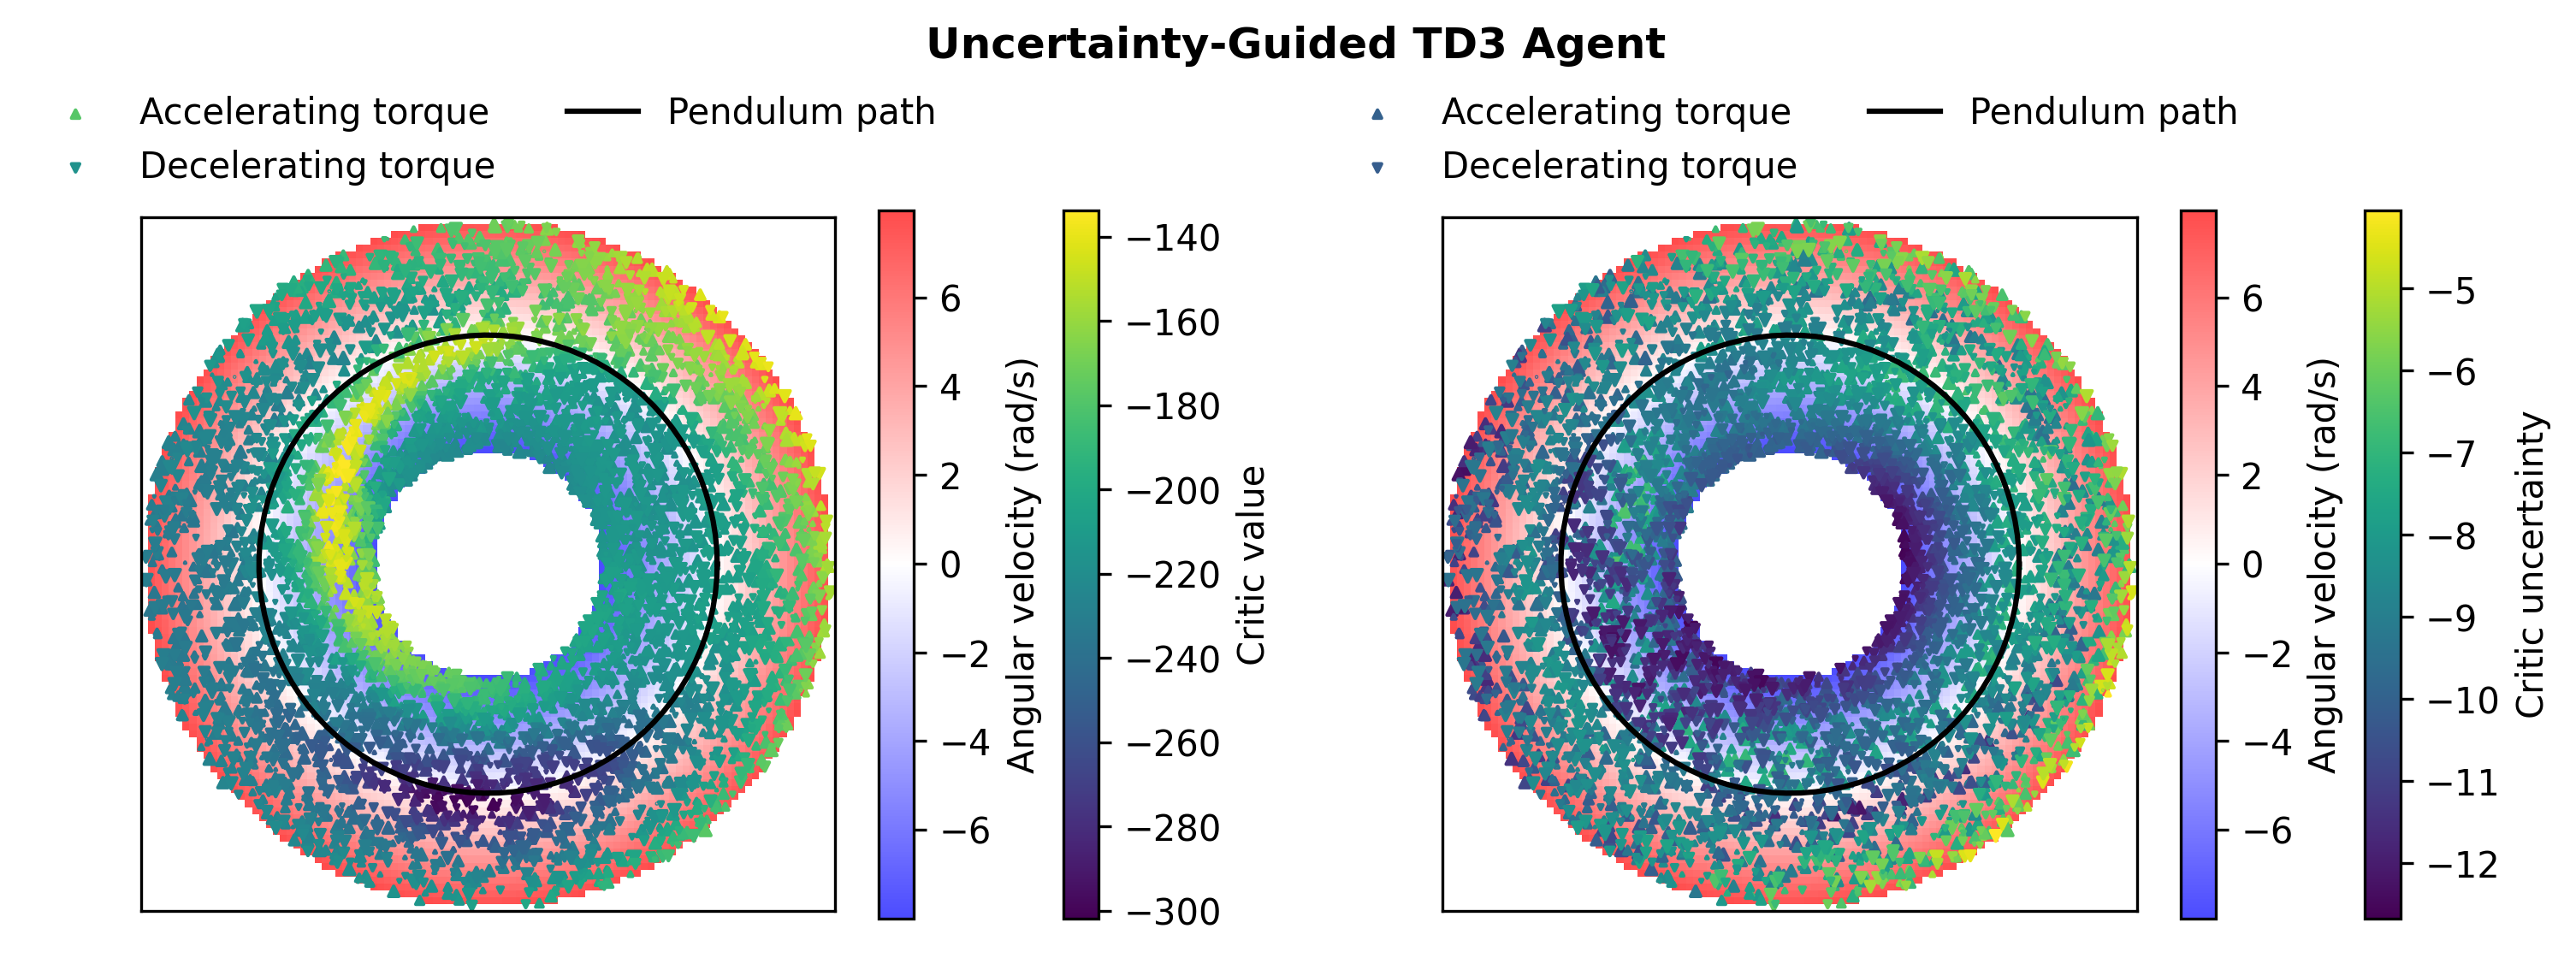

In [10]:
agent_id = 'KerasUncertaintyTD3-v0'
logdir = glob.glob(f'./results/Pendulum/*{agent_id}*')[0]

buffer_type = 'ER-v0'
buffer_size = None

agent = agents.make(
    agent_id, 
    env=env, 
    logdir=logdir, 
    buffer_type=buffer_type, 
    buffer_size=buffer_size,
)

checkpoints = sorted(glob.glob(f'{logdir}/models/epoch_*'))
agent.model_load_path = checkpoints[-1]
print(os.path.basename(agent.model_load_path))
agent.load()

N = 5000
theta = np.random.uniform(low=0, high=2*np.pi, size=(N, 1))
omega = np.random.uniform(low=-8, high=8, size=(N, 1))
states = np.concatenate([np.cos(theta), np.sin(theta), omega], axis=1)
actions = np.random.uniform(low=env.action_space.low, high=env.action_space.high, 
                            size=(N, env.action_space.shape[0]))

critic_values, critic_uncs = agent.critic_model1(states, actions, training=False)
critic_values = critic_values.numpy()
critic_uncs = critic_uncs.numpy()
actor_values = agent.actor_model(states, training=False).numpy()

fig, ax = plt.subplots(1, 2, dpi=300, figsize=(12, 4))

plot_pendulum_space(ax[0], actions, critic_values, theta, omega, vmin=None, vmax=None)
plot_pendulum_space(ax[1], actions, critic_uncs, theta, omega, 
                    vmin=None, vmax=None, label='Critic uncertainty')

fig.subplots_adjust(top=0.8)
fig.suptitle('Uncertainty-Guided TD3 Agent', fontweight='bold')

2024-07-02 15:32:28,595 ERROR:CfgLogger:Problem with key request using None
2024-07-02 15:32:28,601 INFO:Buffer:Buffer config saved successfully
2024-07-02 15:32:28,604 ERROR:Actor:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-07-02 15:32:28,607 ERROR:Actor:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-07-02 15:32:28,627 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-07-02 15:32:28,629 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-07-02 15:32:28,751 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-07-02 15:32:28,754 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number o

Attempting to load jlab_opt_control.agents with KerasSINDyCriticTD3
Attempting to load jlab_opt_control.buffers with ER
Attempting to load jlab_opt_control.models with ActorFCNN
Attempting to load jlab_opt_control.models with ActorFCNN
Attempting to load jlab_opt_control.models with CriticFCNN
Attempting to load jlab_opt_control.models with CriticFCNN
Attempting to load jlab_opt_control.models with CriticFCNN
Attempting to load jlab_opt_control.models with CriticFCNN
degree: 5, <class 'int'>
include_bias: True, <class 'bool'>
include_interaction: True, <class 'bool'>
Attempting to load jlab_opt_control.models with SINDyNetwork
epoch_249


Text(0.5, 0.98, 'SINDy TD3 Agent (R2 = 0.779)')

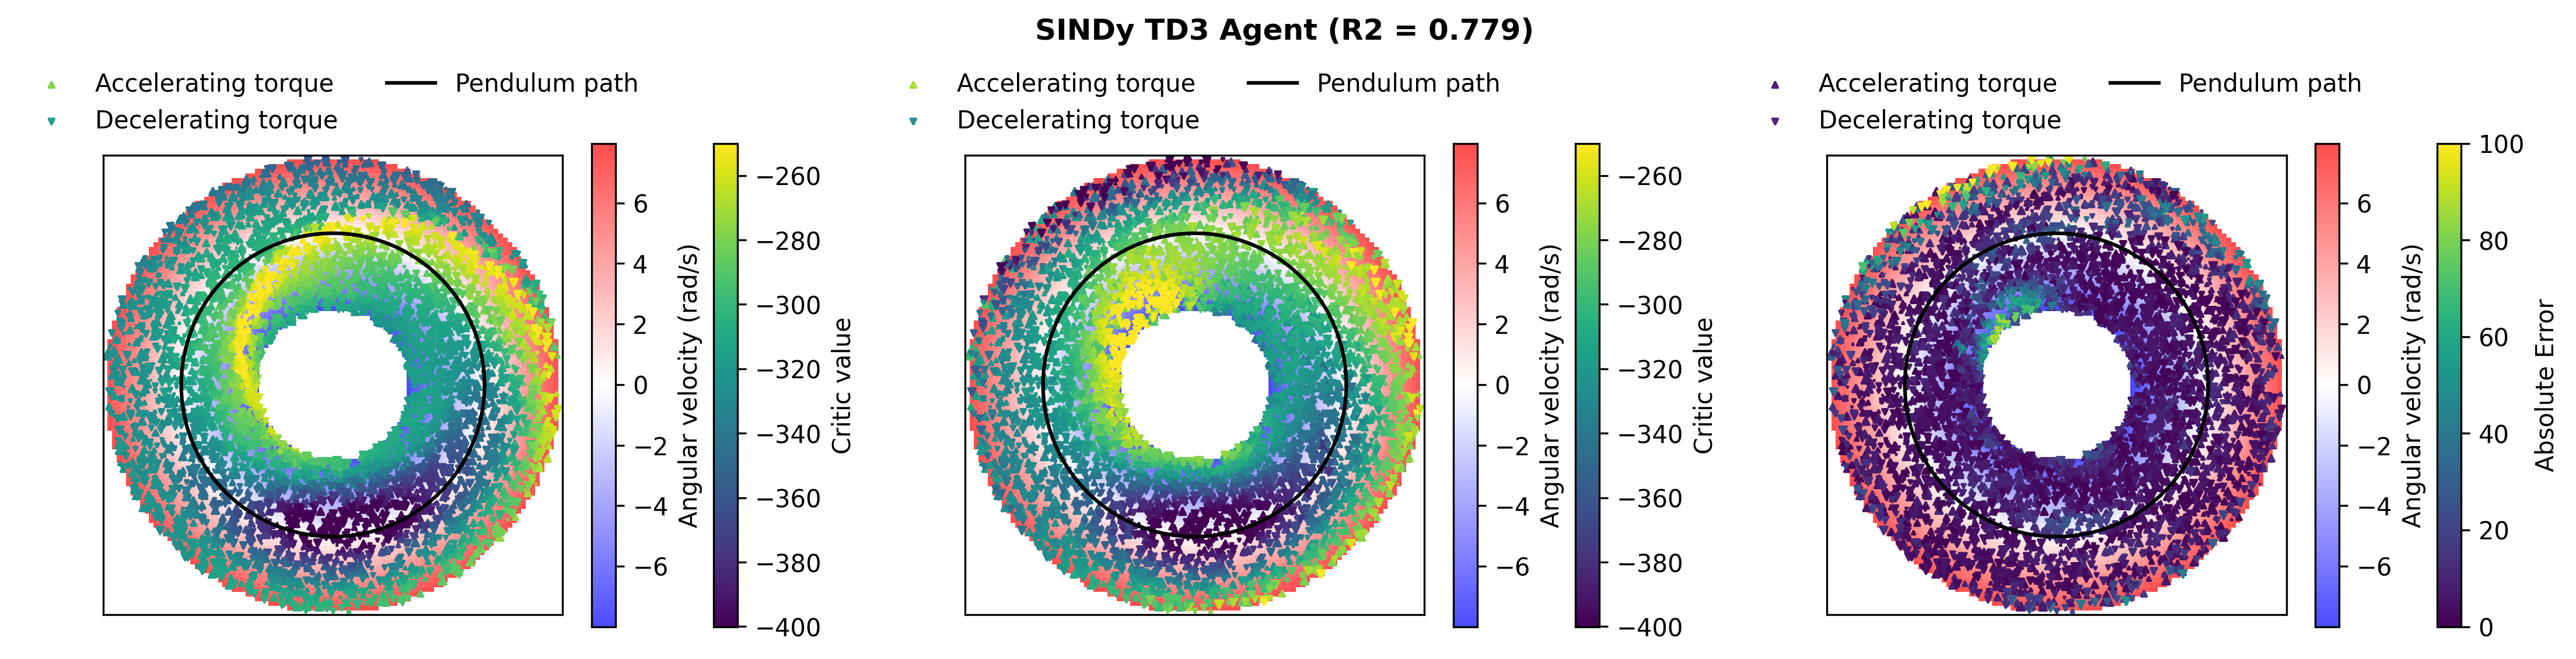

In [10]:
agent_id = 'KerasSINDyCriticTD3-v0'
logdir = glob.glob(f'./results/Pendulum/*{agent_id}*')[0]

buffer_type = 'ER-v0'
buffer_size = None

agent = agents.make(
    agent_id, 
    env=env, 
    logdir=logdir, 
    buffer_type=buffer_type, 
    buffer_size=buffer_size,
)

checkpoints = sorted(glob.glob(f'{logdir}/models/epoch_*'))
agent.model_load_path = checkpoints[-1]
print(os.path.basename(agent.model_load_path))
agent.load()

N = 5000
theta = np.random.uniform(low=0, high=2*np.pi, size=(N, 1))
omega = np.random.uniform(low=-8, high=8, size=(N, 1))
states = np.concatenate([np.cos(theta), np.sin(theta), omega], axis=1)
actions = np.random.uniform(low=env.action_space.low, high=env.action_space.high, 
                            size=(N, env.action_space.shape[0]))
states_actions = tf.keras.layers.Concatenate(axis=1)([states, actions])
lib_batch = agent.library(states_actions)

critic_values = agent.critic_model1(states, actions, training=False).numpy()
sindy_values = agent.critic_sindy(lib_batch).numpy()
actor_values = agent.actor_model(states, training=False).numpy()

fig, ax = plt.subplots(1, 3, dpi=300, figsize=(18, 4))

plot_pendulum_space(ax[0], actions, critic_values, theta, omega, vmin=-400, vmax=-250)
plot_pendulum_space(ax[1], actions, sindy_values, theta, omega, vmin=-400, vmax=-250)
plot_pendulum_space(ax[2], actions, np.abs(critic_values - sindy_values), theta, omega,
                    vmin=0, vmax=100, label='Absolute Error')

from sklearn.metrics import r2_score

fig.subplots_adjust(top=0.8)
fig.suptitle(f'SINDy TD3 Agent (R2 = {r2_score(critic_values, sindy_values):.3f})', fontweight='bold')


2024-07-02 15:32:20,524 ERROR:CfgLogger:Problem with key request using None
2024-07-02 15:32:20,529 INFO:Buffer:Buffer config saved successfully
2024-07-02 15:32:20,531 ERROR:Actor:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-07-02 15:32:20,533 ERROR:Actor:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-07-02 15:32:20,552 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-07-02 15:32:20,555 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-07-02 15:32:20,679 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-07-02 15:32:20,683 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number o

Attempting to load jlab_opt_control.agents with KerasSINDyUncertaintyTD3
Attempting to load jlab_opt_control.buffers with ER
Attempting to load jlab_opt_control.models with ActorFCNN
Attempting to load jlab_opt_control.models with ActorFCNN
Attempting to load jlab_opt_control.models with CriticFCNN
Attempting to load jlab_opt_control.models with CriticFCNN
Attempting to load jlab_opt_control.models with CriticFCNN
Attempting to load jlab_opt_control.models with CriticFCNN
degree: 5, <class 'int'>
include_bias: True, <class 'bool'>
include_interaction: True, <class 'bool'>
Attempting to load jlab_opt_control.models with SINDyNetwork
epoch_249


Text(0.5, 0.98, 'SINDy TD3 Agent (R2 = -0.580)')

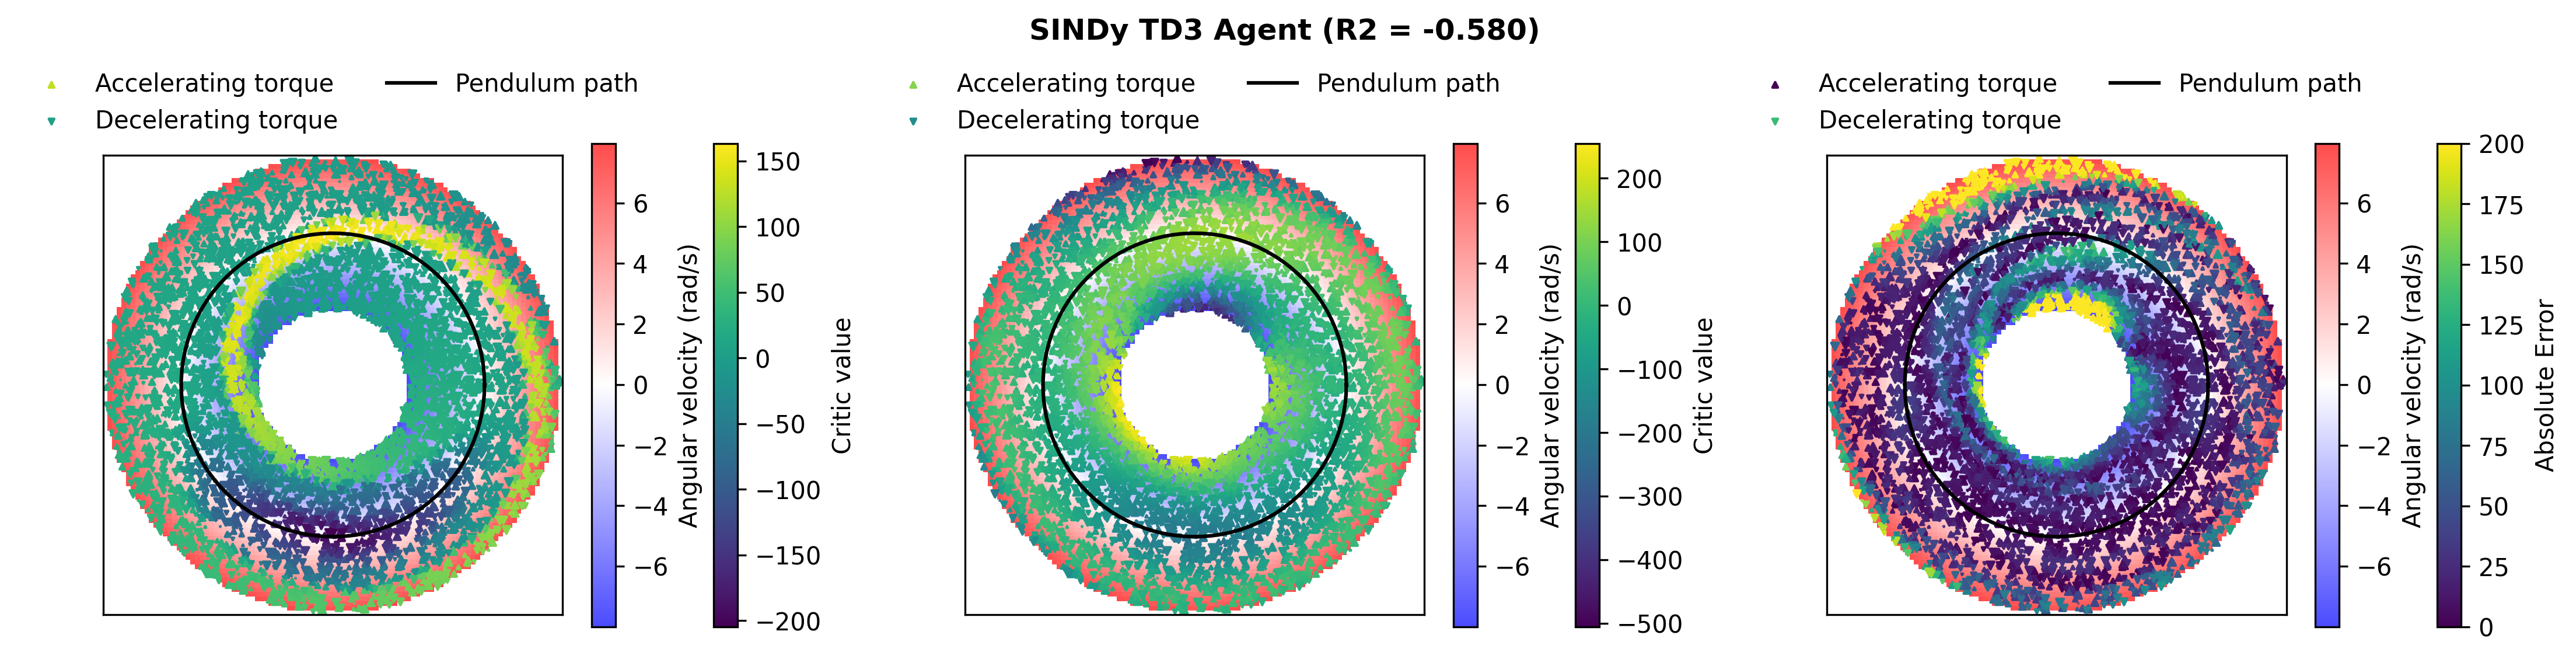

In [9]:
agent_id = 'KerasSINDyUncertaintyTD3-v0'
logdir = glob.glob(f'./results/Pendulum/*{agent_id}*')[1]

buffer_type = 'ER-v0'
buffer_size = None

agent = agents.make(
    agent_id, 
    env=env, 
    logdir=logdir, 
    buffer_type=buffer_type, 
    buffer_size=buffer_size,
)

checkpoints = sorted(glob.glob(f'{logdir}/models/epoch_*'))
agent.model_load_path = checkpoints[-1]
print(os.path.basename(agent.model_load_path))
agent.load()

N = 5000
theta = np.random.uniform(low=0, high=2*np.pi, size=(N, 1))
omega = np.random.uniform(low=-8, high=8, size=(N, 1))
states = np.concatenate([np.cos(theta), np.sin(theta), omega], axis=1)
actions = np.random.uniform(low=env.action_space.low, high=env.action_space.high, 
                            size=(N, env.action_space.shape[0]))
states_actions = tf.keras.layers.Concatenate(axis=1)([states, actions])
lib_batch = agent.library(states_actions)

critic_values = agent.critic_model1(states, actions, training=False).numpy()
sindy_values = agent.critic_sindy(lib_batch).numpy()
actor_values = agent.actor_model(states, training=False).numpy()

fig, ax = plt.subplots(1, 3, dpi=300, figsize=(18, 4))

plot_pendulum_space(ax[0], actions, critic_values, theta, omega, vmin=None, vmax=None)
plot_pendulum_space(ax[1], actions, sindy_values, theta, omega, vmin=None, vmax=None)
plot_pendulum_space(ax[2], actions, np.abs(critic_values - sindy_values), theta, omega,
                    vmin=0, vmax=200, label='Absolute Error')

from sklearn.metrics import r2_score

fig.subplots_adjust(top=0.8)
fig.suptitle(f'SINDy TD3 Agent (R2 = {r2_score(critic_values, sindy_values):.3f})', fontweight='bold')
